# Đồ án Máy học — Nhận dạng thực thể y tế trong hội thoại tiếng Việt (VietMed-NER)

Notebook này tái hiện toàn bộ phần thực nghiệm của báo cáo: mô tả dữ liệu, EDA, tiền xử lý, huấn luyện ba mô hình cổ điển (Logistic Regression, Linear SVM, CRF), chấm ba Transformer (XLM-RoBERTa, PhoBERT, ViHealthBERT), so sánh mô hình, phân tích overfitting/underfitting, confusion matrix và phân tích lỗi. Mọi bảng và hình của báo cáo Word được sinh từ thư mục `results/` mà notebook này tạo ra.

**Cấu trúc thư mục**

| Đường dẫn | Nội dung |
|---|---|
| `checkpoints/phobert`, `checkpoints/vihealthbert` | Checkpoint PhoBERT và ViHealthBERT do nhóm fine-tune (nộp kèm) |
| `checkpoints/xlmr` | Tuỳ chọn. Nếu không có, notebook tải `leduckhai/VietMed-NER` (subfolder `xlm-roberta-base-VietMed-NER`) từ Hugging Face |
| `data/vietmed-ner/data/*.parquet` | Dữ liệu VietMed-NER; tự tải từ Hugging Face nếu chưa có (~850 MB) |
| `ket_qua_goc/` | Kết quả từ các notebook huấn luyện gốc: dò siêu tham số PhoBERT/ViHealthBERT, đo tốc độ, LoRA sửa lỗi transcript, đường cong học ViHealthBERT |
| `results/` | Kết quả do notebook này sinh ra (JSON + PNG) |
| `notebooks_huan_luyen/` | Hai notebook fine-tune gốc của PhoBERT và ViHealthBERT (18 cấu hình × 3 seed) |

**Cách chạy:** Python 3.12, `pip install -r requirements.txt`, sau đó *Restart Kernel → Run All*. Có GPU thì phần Transformer chạy trong khoảng 1 phút; chỉ có CPU thì lâu hơn nhưng vẫn chạy được. Phần mô hình cổ điển mất khoảng 15–20 phút trên CPU.

In [1]:
import json, os, time, unicodedata, itertools
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import torch
import matplotlib
import matplotlib.pyplot as plt
import sklearn_crfsuite
from huggingface_hub import snapshot_download
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score
from seqeval.metrics.sequence_labeling import get_entities
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from transformers import AutoModelForTokenClassification, AutoTokenizer

ROOT = Path.cwd()
DATA_DIR = ROOT / 'data'
CKPT = ROOT / 'checkpoints'
PRIOR = ROOT / 'ket_qua_goc'
RES = ROOT / 'results'
RES.mkdir(exist_ok=True)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
# Đặt True để huấn luyện lại ViHealthBERT và ghi đường cong học theo epoch (~3 phút GPU, cần tải base model ~540 MB).
RETRAIN_CURVE = False
# Tuỳ chọn: thư mục chứa parquet gốc của leduckhai/VietMed để đối chiếu nguồn gốc từng câu.
VIETMED_DIR = Path(os.environ.get('VIETMED_DIR', DATA_DIR / 'vietmed' / 'data'))
pd.set_option('display.precision', 4)
print('Device:', DEVICE, '| torch', torch.__version__)

Device: cuda | torch 2.8.0+cu128


## 1. Tải dữ liệu và mô tả bộ dữ liệu

VietMed-NER gồm transcript hội thoại y tế tiếng Việt, gán nhãn BIO cho 18 loại thực thể (37 nhãn). Nhãn O được lưu dưới dạng chuỗi `"0"`; hàm `load` đổi thành `"O"` để seqeval không coi nó là một loại thực thể.

In [2]:
if not list((DATA_DIR / 'vietmed-ner' / 'data').glob('*.parquet')):
    snapshot_download('leduckhai/VietMed-NER', repo_type='dataset', allow_patterns=['data/*.parquet'],
                      local_dir=DATA_DIR / 'vietmed-ner')

SPLITS = ('train', 'validation', 'test')


def norm_tag(tag):
    return 'O' if str(tag) in ('0', 'O') else str(tag)


def load(split):
    path = next((DATA_DIR / 'vietmed-ner' / 'data').glob(f'{split}-*.parquet'))
    table = pq.read_table(path, columns=['words', 'labels']).to_pydict()
    return table['words'], [[norm_tag(t) for t in row] for row in table['labels']]


data = {s: load(s) for s in SPLITS}
eda = {}
for s, (words, tags) in data.items():
    ents = Counter(t for row in tags for t, _, _ in get_entities(row))
    lengths = [len(w) for w in words]
    n_tok = sum(lengths)
    eda[s] = {'sentences': len(words), 'tokens': n_tok, 'len_mean': float(np.mean(lengths)),
              'len_median': float(np.median(lengths)), 'len_max': int(max(lengths)),
              'sentences_without_entity': sum(1 for r in tags if all(t == 'O' for t in r)),
              'o_token_ratio': sum(t == 'O' for r in tags for t in r) / n_tok,
              'entity_spans': dict(ents.most_common()), 'entity_total': sum(ents.values())}
(RES / 'eda.json').write_text(json.dumps(eda, ensure_ascii=False, indent=2))
labels_all = sorted({t for _, tags in data.values() for r in tags for t in r})
print('Số nhãn BIO:', len(labels_all))
pd.DataFrame({s: {k: v for k, v in e.items() if k != 'entity_spans'} for s, e in eda.items()}).T

Số nhãn BIO: 37


,sentences,tokens,len_mean,len_median,len_max,sentences_without_entity,o_token_ratio,entity_total
train,4616.0,111267.0,24.1046,26.0,40.0,440.0,0.7848,11747.0
validation,1154.0,27657.0,23.9662,26.0,38.0,105.0,0.7871,2889.0
test,3497.0,77675.0,22.2119,20.0,40.0,353.0,0.7877,8338.0


In [3]:
entity_table = pd.DataFrame({s: eda[s]['entity_spans'] for s in SPLITS}).fillna(0).astype(int)
entity_table = entity_table.sort_values('train', ascending=False)
entity_table['train_%'] = (100 * entity_table['train'] / entity_table['train'].sum()).round(1)
entity_table['test_%'] = (100 * entity_table['test'] / entity_table['test'].sum()).round(1)
print('Tỉ lệ lớp lớn nhất / nhỏ nhất (train):', entity_table['train'].max() / entity_table['train'].min())
entity_table

Tỉ lệ lớp lớn nhất / nhỏ nhất (train): 595.0


,train,validation,test,train_%,test_%
DISEASESYMTOM,2975,746,1467,25.3,17.6
ORGAN,1972,485,1260,16.8,15.1
DRUGCHEMICAL,1127,278,709,9.6,8.5
UNITCALIBRATOR,822,220,257,7.0,3.1
TREATMENT,740,178,232,6.3,2.8
DATETIME,698,166,667,5.9,8.0
OCCUPATION,547,134,565,4.7,6.8
AGE,456,109,622,3.9,7.5
PERSONALCARE,384,89,95,3.3,1.1
DIAGNOSTICS,373,91,299,3.2,3.6


## 2. Phân tích dữ liệu (EDA)

Dữ liệu là văn bản dạng chuỗi, nên EDA tập trung vào: phân bố lớp và mất cân bằng, độ dài câu và độ dài thực thể, từ vựng và tỉ lệ từ chưa gặp (OOV) giữa các tập, và nguồn gốc các tập.

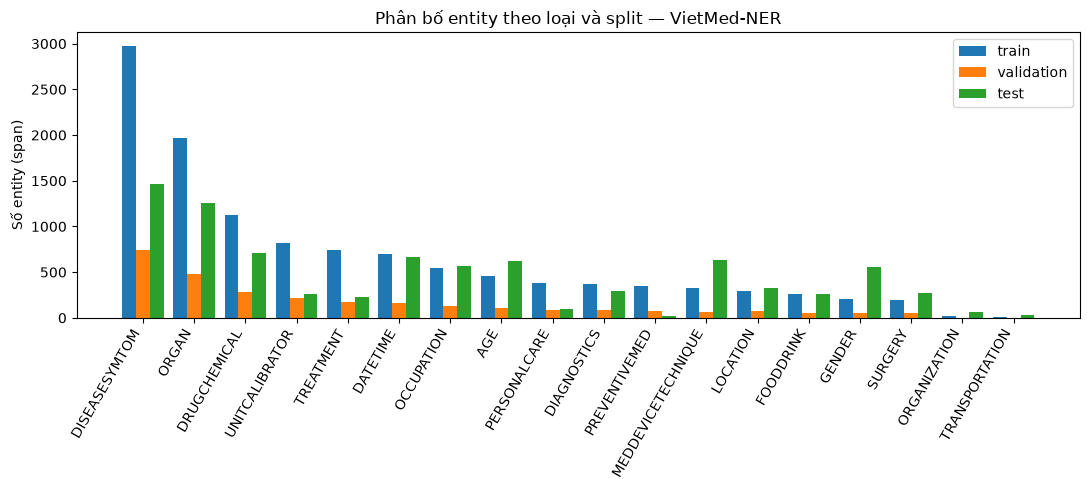

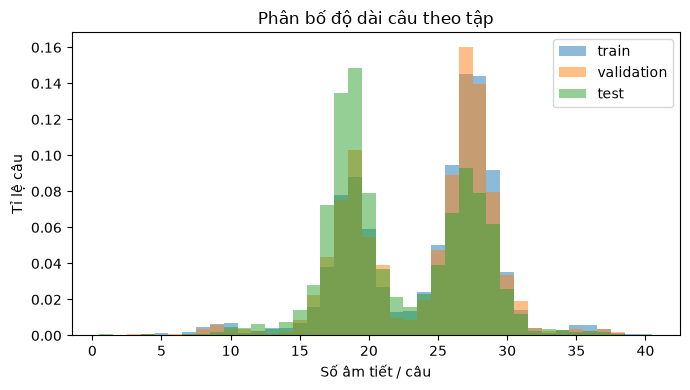

Độ dài entity trong train (âm tiết → số entity): {1: 2856, 2: 6875, 3: 1116, 4: 655, 5: 137, 6: 86, 7: 11, 8: 6, 9: 4, 11: 1}


In [4]:
order = list(entity_table.index)
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(order))
for i, s in enumerate(SPLITS):
    ax.bar(x + (i - 1) * 0.27, [eda[s]['entity_spans'].get(t, 0) for t in order], 0.27, label=s)
ax.set_xticks(x, order, rotation=60, ha='right')
ax.set_ylabel('Số entity (span)')
ax.set_title('Phân bố entity theo loại và split — VietMed-NER')
ax.legend()
fig.tight_layout()
fig.savefig(RES / 'fig_entity_distribution.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
for s in SPLITS:
    ax.hist([len(w) for w in data[s][0]], bins=np.arange(0.5, 41.5, 1), alpha=0.5, label=s, density=True)
ax.set_xlabel('Số âm tiết / câu')
ax.set_ylabel('Tỉ lệ câu')
ax.set_title('Phân bố độ dài câu theo tập')
ax.legend()
fig.tight_layout()
fig.savefig(RES / 'fig_sentence_length.png', dpi=150)
plt.show()

entity_len = Counter(e - s + 1 for row in data['train'][1] for _, s, e in get_entities(row))
print('Độ dài entity trong train (âm tiết → số entity):', dict(sorted(entity_len.items())))

### 2.1 Kiểm tra chất lượng, từ vựng/OOV và nguồn gốc các tập

In [5]:
quality = {}
for s, (words, tags) in data.items():
    invalid = 0
    for row in tags:
        prev = 'O'
        for t in row:
            if t.startswith('I-') and not (prev != 'O' and prev[2:] == t[2:]):
                invalid += 1
            prev = t
    quality[s] = {'length_mismatch': sum(len(w) != len(t) for w, t in zip(words, tags)),
                  'empty_sentences': sum(len(w) == 0 for w in words),
                  'empty_tokens': sum(1 for w in words for x in w if not str(x).strip()),
                  'non_nfc_tokens': sum(1 for w in words for x in w if unicodedata.normalize('NFC', x) != x),
                  'uppercase_tokens': sum(1 for w in words for x in w if x != x.lower()),
                  'punctuation_only_tokens': sum(1 for w in words for x in w if not any(c.isalnum() for c in x)),
                  'invalid_bio_I_after_O': invalid}

train_vocab = Counter(x for w in data['train'][0] for x in w)
train_surface = {' '.join(w[s:e + 1]) for w, t in zip(*data['train']) for _, s, e in get_entities(t)}
oov = {'train_vocab': len(train_vocab)}
for s in ('validation', 'test'):
    toks = [x for w in data[s][0] for x in w]
    ents = [' '.join(w[a:b + 1]) for w, t in zip(*data[s]) for _, a, b in get_entities(t)]
    oov[s] = {'vocab': len(set(toks)), 'token_oov_rate': sum(x not in train_vocab for x in toks) / len(toks),
              'type_oov_rate': len({x for x in toks if x not in train_vocab}) / len(set(toks)),
              'unseen_entity_rate': sum(e not in train_surface for e in ents) / len(ents)}

if list(VIETMED_DIR.glob('*.parquet')):
    source = {}
    for sp in ('train', 'dev', 'test', 'cv'):
        texts = pq.read_table(next(VIETMED_DIR.glob(f'{sp}-*.parquet')), columns=['text']).column('text').to_pylist()
        for text in texts:
            source.setdefault(' '.join(text.lower().split()), sp)
    lineage = {s: dict(Counter(source.get(' '.join(' '.join(w).lower().split()), 'no_exact_match') for w in data[s][0]))
               for s in SPLITS}
else:
    lineage = json.loads((PRIOR / 'data_lineage.json').read_text())
    print('Không có parquet VietMed gốc — dùng kết quả đối chiếu đã lưu trong ket_qua_goc/data_lineage.json')

(RES / 'data_quality.json').write_text(json.dumps({'quality': quality, 'oov': oov, 'lineage': lineage}, indent=1))
display(pd.DataFrame(quality))
display(pd.DataFrame({k: v for k, v in oov.items() if k != 'train_vocab'}))
pd.DataFrame(lineage).fillna(0).astype(int)

,train,validation,test
length_mismatch,0,0,0
empty_sentences,0,0,0
empty_tokens,0,0,0
non_nfc_tokens,0,0,0
uppercase_tokens,0,0,0
punctuation_only_tokens,0,0,0
invalid_bio_I_after_O,16,0,7


,validation,test
vocab,1526.0000,2129.0000
token_oov_rate,0.0042,0.0183
type_oov_rate,0.0636,0.2273
unseen_entity_rate,0.0668,0.3065


,train,validation,test
train,2214,559,0
dev,2331,581,0
cv,71,14,0
test,0,0,3437
no_exact_match,0,0,60


**Nhận xét.** Dữ liệu không có giá trị thiếu, đã viết thường và chuẩn hoá NFC, nên không phải điền hay loại bỏ mẫu nào; 23 chuỗi BIO lỗi được giữ nguyên để không thay đổi tập đánh giá chính thức. Train và validation được chia ngẫu nhiên từ cùng nguồn VietMed train+dev+cv, còn test là VietMed test (bản ghi khác, chủ đề bệnh khác). Khoảng 30,7% thực thể của test chưa từng xuất hiện ở train, so với 6,7% ở validation: đây là lệch miền.

## 3. Tiền xử lý và mã hoá

- **Mô hình cổ điển:** mỗi âm tiết được biểu diễn bằng đặc trưng thủ công (âm tiết, là số, độ dài, tiền tố/hậu tố 2 ký tự, cửa sổ ±2, bigram), rồi `DictVectorizer` chuyển thành vector thưa one-hot.
- **Transformer:** tokenizer tách âm tiết thành subword; nhãn chỉ gán cho subword đầu, các subword còn lại nhận -100.

In [6]:
def word_features(words, i):
    w = words[i]
    f = {'bias': 1.0, 'w.lower': w.lower(), 'w.istitle': w.istitle(), 'w.isdigit': w.isdigit(),
         'w.len': min(len(w), 8), 'suf2': w[-2:].lower(), 'pre2': w[:2].lower()}
    for off in (-2, -1, 1, 2):
        j = i + off
        if 0 <= j < len(words):
            f[f'{off}:w.lower'] = words[j].lower()
            f[f'{off}:w.istitle'] = words[j].istitle()
            if abs(off) == 1:
                lo, hi = sorted((i, j))
                f[f'{off}:bigram'] = f'{words[lo].lower()}_{words[hi].lower()}'
        else:
            f[f'{off}:pad'] = True
    return f


def featurize(sents):
    return [[word_features(s, i) for i in range(len(s))] for s in sents]


def flat(x):
    return [t for sent in x for t in sent]


def unflat(flat_tags, like):
    out, i = [], 0
    for sent in like:
        out.append([str(t) for t in flat_tags[i:i + len(sent)]])
        i += len(sent)
    return out


feats = {s: featurize(data[s][0]) for s in SPLITS}
vec = DictVectorizer()
X = {'train': vec.fit_transform(flat(feats['train']))}
X.update({s: vec.transform(flat(feats[s])) for s in ('validation', 'test')})
for s in X:  # liblinear (LinearSVC) cần chỉ số thưa 32-bit
    X[s] = X[s].tocsr()
    X[s].indices = X[s].indices.astype(np.int32)
    X[s].indptr = X[s].indptr.astype(np.int32)
y_train = flat(data['train'][1])
print('Số token train:', X['train'].shape[0], '| số chiều đặc trưng:', X['train'].shape[1])

Số token train: 111267 | số chiều đặc trưng: 77424


## 4. Mô hình cổ điển: Logistic Regression, Linear SVM, CRF

Siêu tham số được chọn theo F1 trên validation. Logistic Regression và Linear SVM phân loại từng âm tiết độc lập; CRF học thêm xác suất chuyển giữa các nhãn liền kề.

In [7]:
preds = {s: {} for s in SPLITS}
classical_log = {}
for name, make, grid in [
    ('Logistic Regression', lambda c: LogisticRegression(C=c, max_iter=300), [0.1, 1.0, 10.0, 30.0]),
    ('Linear SVM', lambda c: LinearSVC(C=c, max_iter=5000), [0.01, 0.1, 1.0, 3.0, 10.0]),
]:
    trials = []
    for c in grid:
        t0 = time.time()
        clf = make(c).fit(X['train'], y_train)
        val = f1_score(data['validation'][1], unflat(clf.predict(X['validation']), data['validation'][1]), zero_division=0)
        trials.append({'C': c, 'val_f1': float(val), 'seconds': round(time.time() - t0, 1)})
        print(name, trials[-1])
    best = max(trials, key=lambda t: t['val_f1'])
    t0 = time.time()
    clf = make(best['C']).fit(X['train'], y_train)
    classical_log[name] = {'trials': trials, 'best': best, 'fit_seconds': round(time.time() - t0, 1)}
    for s in SPLITS:
        preds[s][name] = unflat(clf.predict(X[s]), data[s][1])

Logistic Regression {'C': 0.1, 'val_f1': 0.7068575734740015, 'seconds': 87.4}


Logistic Regression {'C': 1.0, 'val_f1': 0.8223649939225559, 'seconds': 116.5}


/tmp/claude-1000/-home-hieu--herdr-worktrees-VoDoCo-slide-machine-learning/0a42cce8-3cd0-4512-8cc3-13fe2276a5e8/scratchpad/pylib/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression {'C': 10.0, 'val_f1': 0.8320819112627987, 'seconds': 116.1}


Logistic Regression {'C': 30.0, 'val_f1': 0.8265219603188062, 'seconds': 110.5}


...

Linear SVM {'C': 0.01, 'val_f1': 0.7046303211351754, 'seconds': 8.5}


Linear SVM {'C': 0.1, 'val_f1': 0.8321823204419889, 'seconds': 10.0}


Linear SVM {'C': 1.0, 'val_f1': 0.8453085376162299, 'seconds': 15.4}


Linear SVM {'C': 3.0, 'val_f1': 0.8381784574021173, 'seconds': 18.5}


Linear SVM {'C': 10.0, 'val_f1': 0.8173970783532537, 'seconds': 36.9}


In [8]:
crf_trials = []
for c1, c2 in itertools.product([0.01, 0.1, 0.5], [0.01, 0.1, 1.0]):
    m = sklearn_crfsuite.CRF(algorithm='lbfgs', c1=c1, c2=c2, max_iterations=200, all_possible_transitions=True)
    m.fit(feats['train'], data['train'][1])
    crf_trials.append({'c1': c1, 'c2': c2, 'val_f1': float(f1_score(data['validation'][1], m.predict(feats['validation']), zero_division=0))})
    print(crf_trials[-1])
crf_best = max(crf_trials, key=lambda t: t['val_f1'])
t0 = time.time()
crf = sklearn_crfsuite.CRF(algorithm='lbfgs', c1=crf_best['c1'], c2=crf_best['c2'], max_iterations=200, all_possible_transitions=True)
crf.fit(feats['train'], data['train'][1])
classical_log['CRF'] = {'trials': crf_trials, 'best': {'c1': crf_best['c1'], 'c2': crf_best['c2']}, 'fit_seconds': round(time.time() - t0, 1)}
for s in SPLITS:
    preds[s]['CRF'] = [[str(t) for t in row] for row in crf.predict(feats[s])]

# Đường cong học của CRF theo kích thước tập train
perm = np.random.default_rng(0).permutation(len(feats['train']))
crf_curve = []
for frac in (0.1, 0.25, 0.5, 0.75, 1.0):
    idx = perm[:int(frac * len(perm))]
    m = sklearn_crfsuite.CRF(algorithm='lbfgs', c1=crf_best['c1'], c2=crf_best['c2'], max_iterations=200, all_possible_transitions=True)
    m.fit([feats['train'][i] for i in idx], [data['train'][1][i] for i in idx])
    row = {'fraction': frac, 'sentences': int(len(idx)),
           'train_f1': float(f1_score([data['train'][1][i] for i in idx], m.predict([feats['train'][i] for i in idx]), zero_division=0))}
    for s in ('validation', 'test'):
        row[f'{s}_f1'] = float(f1_score(data[s][1], m.predict(feats[s]), zero_division=0))
    crf_curve.append(row)
pd.DataFrame(crf_curve)

{'c1': 0.01, 'c2': 0.01, 'val_f1': 0.8892050506846878}


{'c1': 0.01, 'c2': 0.1, 'val_f1': 0.8836376655925529}


{'c1': 0.01, 'c2': 1.0, 'val_f1': 0.8469724770642202}


{'c1': 0.1, 'c2': 0.01, 'val_f1': 0.8915236241373208}


{'c1': 0.1, 'c2': 0.1, 'val_f1': 0.8863514719000892}


{'c1': 0.1, 'c2': 1.0, 'val_f1': 0.845984598459846}


{'c1': 0.5, 'c2': 0.01, 'val_f1': 0.8772492428291466}


{'c1': 0.5, 'c2': 0.1, 'val_f1': 0.8688025774118491}


{'c1': 0.5, 'c2': 1.0, 'val_f1': 0.8377483443708609}


,fraction,sentences,train_f1,validation_f1,test_f1
0,0.10,461,0.9996,0.7028,0.4108
1,0.25,1154,0.9998,0.7917,0.4782
2,0.50,2308,0.9997,0.8421,0.5687
3,0.75,3462,0.9997,0.8677,0.6239
4,1.00,4616,0.9996,0.8920,0.6379


## 5. Ba mô hình Transformer

PhoBERT và ViHealthBERT được nhóm fine-tune trong `notebooks_huan_luyen/` (lưới 18 cấu hình × 3 seed; chọn seed theo validation). XLM-RoBERTa là checkpoint của tác giả bộ dữ liệu, dùng làm mốc so sánh. Dự đoán dùng cùng cách căn nhãn theo subword đầu như khi huấn luyện.

In [9]:
TRANSFORMERS = {
    'XLM-R': CKPT / 'xlmr' if (CKPT / 'xlmr').exists() else ('leduckhai/VietMed-NER', 'xlm-roberta-base-VietMed-NER'),
    'PhoBERT': CKPT / 'phobert',
    'ViHealthBERT': CKPT / 'vihealthbert',
}


def load_model(spec):
    if isinstance(spec, tuple):
        repo, sub = spec
        return AutoTokenizer.from_pretrained(repo, subfolder=sub), AutoModelForTokenClassification.from_pretrained(repo, subfolder=sub)
    return AutoTokenizer.from_pretrained(spec), AutoModelForTokenClassification.from_pretrained(spec)


def encode(words, tok, max_len=256):
    raw, wids = [], []
    for i, w in enumerate(words):
        sub = tok.encode(w, add_special_tokens=False)
        raw += sub
        wids += [i] * len(sub)
    ids = tok.build_inputs_with_special_tokens(raw)
    start = next(s for s in range(len(ids) - len(raw) + 1) if ids[s:s + len(raw)] == raw)
    word_ids = [None] * len(ids)
    for k, pos in enumerate(range(start, start + len(raw))):
        word_ids[pos] = wids[k]
    return ids[:max_len], word_ids[:max_len]


def predict(tok, model, sents, batch=32):
    id2 = {int(k): v for k, v in model.config.id2label.items()}
    out = []
    for i in range(0, len(sents), batch):
        enc = [encode(s, tok) for s in sents[i:i + batch]]
        width = max(len(x) for x, _ in enc)
        ids = torch.tensor([x + [tok.pad_token_id] * (width - len(x)) for x, _ in enc], device=DEVICE)
        mask = torch.tensor([[1] * len(x) + [0] * (width - len(x)) for x, _ in enc], device=DEVICE)
        with torch.inference_mode():
            arg = model(input_ids=ids, attention_mask=mask).logits.argmax(-1).cpu().tolist()
        for (x, wid), row, s in zip(enc, arg, sents[i:i + batch]):
            tags, seen = ['O'] * len(s), set()
            for t, w in zip(row, wid):
                if w is not None and w not in seen:
                    seen.add(w)
                    tags[w] = norm_tag(id2[t])
            out.append(tags)
    return out


for name, spec in TRANSFORMERS.items():
    tok, model = load_model(spec)
    model = model.to(DEVICE).eval()
    for s in SPLITS:
        preds[s][name] = predict(tok, model, data[s][0])
    print(name, 'test F1 =', round(f1_score(data['test'][1], preds['test'][name], zero_division=0), 4))
    del model
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()

/home/hieu/Work/Learning.UIT/VoDoCo/experiments/002-vietmed-correction-training/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:829: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


XLM-R test F1 = 0.5862


PhoBERT test F1 = 0.6242


ViHealthBERT test F1 = 0.6274


## 6. Đánh giá và so sánh sáu mô hình

Thước đo chính là F1 mức thực thể của seqeval (khớp chính xác ranh giới và loại). Kèm theo: precision, recall, macro F1, accuracy mức token, F1 kiểu SLUE (cách chấm của bài báo gốc, để đối chiếu), recall theo thực thể đã gặp/chưa gặp trong train, và paired bootstrap 2.000 lần cho khoảng tin cậy.

In [10]:
ORDER = ['Logistic Regression', 'Linear SVM', 'CRF', 'XLM-R', 'PhoBERT', 'ViHealthBERT']
gold, words = data['test'][1], data['test'][0]
gold_sets = [set(get_entities(t)) for t in gold]


def slue_set(ws, tags):
    out = set()
    for word, tag in zip(ws, tags):
        t = tag.split('-')[-1]
        if t == 'O':
            continue
        c = 0
        while (t, word, c) in out:
            c += 1
        out.add((t, word, c))
    return out


def span_outcomes(g_tags, p_tags):
    st = Counter()
    for g, p in zip(g_tags, p_tags):
        gs = {(s, e): t for t, s, e in get_entities(g)}
        ps = {(s, e): t for t, s, e in get_entities(p)}
        used = set()
        for (s, e), t in gs.items():
            if (s, e) in ps:
                used.add((s, e))
                st['exact' if ps[(s, e)] == t else 'wrong_type'] += 1
                continue
            ov = [k for k in ps if k[0] <= e and s <= k[1]]
            if ov:
                st['boundary'] += 1
                used.update(ov)
            else:
                st['missed'] += 1
        st['spurious'] += sum(1 for k in ps if k not in used)
    return dict(st)


def counts(pred):
    ps = [set(get_entities(t)) for t in pred]
    return (np.array([len(a & b) for a, b in zip(gold_sets, ps)]), np.array([len(a) for a in gold_sets]), np.array([len(b) for b in ps]))


def f1c(tp, ng, npd):
    p, r = tp.sum() / max(npd.sum(), 1), tp.sum() / max(ng.sum(), 1)
    return 2 * p * r / (p + r) if p + r else 0.0


gs_slue = [slue_set(w, t) for w, t in zip(words, gold)]
summary, C = {}, {}
for m in ORDER:
    pred = preds['test'][m]
    rep = classification_report(gold, pred, output_dict=True, zero_division=0)
    ps_slue = [slue_set(w, t) for w, t in zip(words, pred)]
    s_tp = sum(len(a & b) for a, b in zip(gs_slue, ps_slue))
    s_p, s_r = s_tp / sum(map(len, ps_slue)), s_tp / sum(map(len, gs_slue))
    pred_sets = [set(get_entities(t)) for t in pred]
    seen = {True: [0, 0], False: [0, 0]}
    for w, g, p in zip(words, gold_sets, pred_sets):
        for ent in g:
            k = ' '.join(w[ent[1]:ent[2] + 1]) in train_surface
            seen[k][0] += ent in p
            seen[k][1] += 1
    by_len = {}
    for lo, hi in [(1, 10), (11, 20), (21, 30), (31, 99)]:
        idx = [i for i, w in enumerate(words) if lo <= len(w) <= hi]
        by_len[f'{lo}-{hi if hi < 99 else "+"}'] = {'sentences': len(idx), 'f1': float(f1_score([gold[i] for i in idx], [pred[i] for i in idx], zero_division=0))}
    C[m] = counts(pred)
    summary[m] = {
        'train_f1': float(f1_score(data['train'][1], preds['train'][m], zero_division=0)),
        'val_f1': float(f1_score(data['validation'][1], preds['validation'][m], zero_division=0)),
        'test_precision': float(precision_score(gold, pred, zero_division=0)),
        'test_recall': float(recall_score(gold, pred, zero_division=0)),
        'test_f1': float(f1_score(gold, pred, zero_division=0)),
        'test_macro_f1': float(rep['macro avg']['f1-score']),
        'test_token_accuracy_bio': float(np.mean([a == b for g, p in zip(gold, pred) for a, b in zip(g, p)])),
        'test_slue_f1': 2 * s_p * s_r / (s_p + s_r),
        'recall_seen': seen[True][0] / seen[True][1], 'recall_unseen': seen[False][0] / seen[False][1],
        'span_outcomes': span_outcomes(gold, pred), 'f1_by_sentence_length': by_len,
        'per_type_f1': {k: float(v['f1-score']) for k, v in rep.items() if 'avg' not in k},
    }

rng = np.random.default_rng(42)
n = len(gold)
boot = {m: [] for m in ORDER}
for _ in range(2000):
    idx = rng.integers(0, n, n)
    for m in ORDER:
        tp, ng, npd = C[m]
        boot[m].append(f1c(tp[idx], ng[idx], npd[idx]))
boot = {m: np.array(v) for m, v in boot.items()}
for m in ORDER:
    summary[m]['test_f1_ci95'] = [float(np.percentile(boot[m], 2.5)), float(np.percentile(boot[m], 97.5))]
pairs = {}
for a, b in [('CRF', 'ViHealthBERT'), ('CRF', 'PhoBERT'), ('ViHealthBERT', 'PhoBERT'), ('PhoBERT', 'XLM-R'),
             ('CRF', 'Linear SVM'), ('Linear SVM', 'Logistic Regression')]:
    d = boot[a] - boot[b]
    pairs[f'{a} - {b}'] = {'delta': summary[a]['test_f1'] - summary[b]['test_f1'],
                           'ci95': [float(np.percentile(d, 2.5)), float(np.percentile(d, 97.5))]}

(RES / 'model_comparison.json').write_text(json.dumps({'models': summary, 'pairs': pairs, 'classical_training': classical_log,
                                                      'crf_learning_curve': crf_curve}, ensure_ascii=False, indent=2))
(RES / 'test_predictions.json').write_text(json.dumps(preds['test']))
cols = ['train_f1', 'val_f1', 'test_precision', 'test_recall', 'test_f1', 'test_macro_f1', 'test_token_accuracy_bio', 'test_slue_f1']
display(pd.DataFrame({m: {c: summary[m][c] for c in cols} for m in ORDER}).T.mul(100).round(2))
pd.DataFrame(pairs).T

,train_f1,val_f1,test_precision,test_recall,test_f1,test_macro_f1,test_token_accuracy_bio,test_slue_f1
Logistic Regression,99.40,83.21,54.73,57.81,56.23,50.59,88.28,66.71
Linear SVM,98.57,84.53,54.59,62.09,58.10,52.92,88.49,67.59
CRF,99.96,89.15,65.78,61.93,63.80,58.06,88.60,68.22
XLM-R,80.55,79.93,52.58,66.24,58.62,48.38,88.00,68.53
PhoBERT,94.89,85.24,56.73,69.39,62.42,51.90,89.30,70.58
ViHealthBERT,96.71,85.18,56.18,71.04,62.74,51.56,89.21,71.82


,delta,ci95
CRF - ViHealthBERT,0.0105,"[0.0008119697460191035, 0.02053134849189308]"
CRF - PhoBERT,0.0137,"[0.004313606251899741, 0.023101276219436778]"
ViHealthBERT - PhoBERT,0.0032,"[-0.004070987516815247, 0.010400184671576052]"
PhoBERT - XLM-R,0.038,"[0.02887931503964101, 0.04818614205006621]"
CRF - Linear SVM,0.057,"[0.049003742035627636, 0.06504302855620028]"
Linear SVM - Logistic Regression,0.0187,"[0.013520212164922194, 0.024169069667774823]"


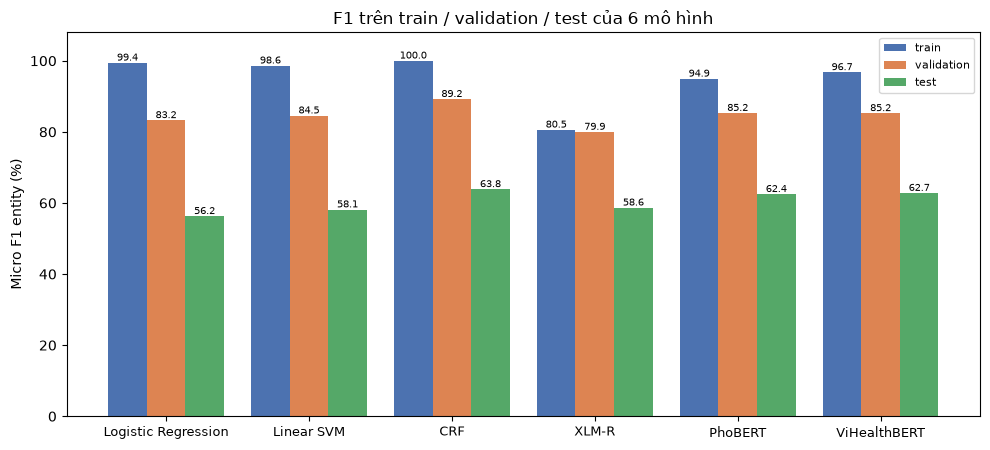

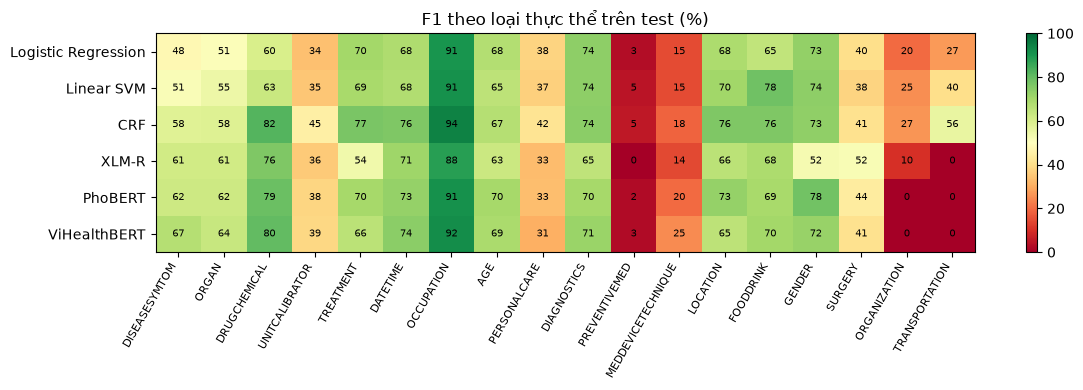

In [11]:
COL = {'train': '#4C72B0', 'validation': '#DD8452', 'test': '#55A868'}
fig, ax = plt.subplots(figsize=(10, 4.6))
x = np.arange(len(ORDER))
for i, (key, lab) in enumerate([('train_f1', 'train'), ('val_f1', 'validation'), ('test_f1', 'test')]):
    b = ax.bar(x + (i - 1) * 0.27, [summary[m][key] * 100 for m in ORDER], 0.27, label=lab, color=COL[lab])
    ax.bar_label(b, fmt='%.1f', fontsize=7)
ax.set_xticks(x, ORDER, fontsize=9)
ax.set_ylabel('Micro F1 entity (%)')
ax.set_ylim(0, 108)
ax.set_title('F1 trên train / validation / test của 6 mô hình')
ax.legend(loc='upper right', fontsize=8)
fig.tight_layout()
fig.savefig(RES / 'fig_f1_by_split.png', dpi=150)
plt.show()

types = list(entity_table.index)
M = np.array([[summary[m]['per_type_f1'].get(t, 0) * 100 for t in types] for m in ORDER])
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(M, cmap='RdYlGn', vmin=0, vmax=100, aspect='auto')
ax.set_xticks(range(len(types)), types, rotation=60, ha='right', fontsize=8)
ax.set_yticks(range(len(ORDER)), ORDER)
for i in range(len(ORDER)):
    for j in range(len(types)):
        ax.text(j, i, f'{M[i, j]:.0f}', ha='center', va='center', fontsize=7)
ax.set_title('F1 theo loại thực thể trên test (%)')
fig.colorbar(im)
fig.tight_layout()
fig.savefig(RES / 'fig_per_type_f1_test.png', dpi=150)
plt.show()

## 7. Train so với validation: overfitting và underfitting

Ba nguồn bằng chứng: (1) lưới dò siêu tham số của PhoBERT/ViHealthBERT (underfit khi learning rate nhỏ, ít epoch); (2) đường cong học của ViHealthBERT theo epoch; (3) đường cong học của CRF theo kích thước tập train. Thêm ví dụ LoRA sửa lỗi transcript ở phần mở rộng.

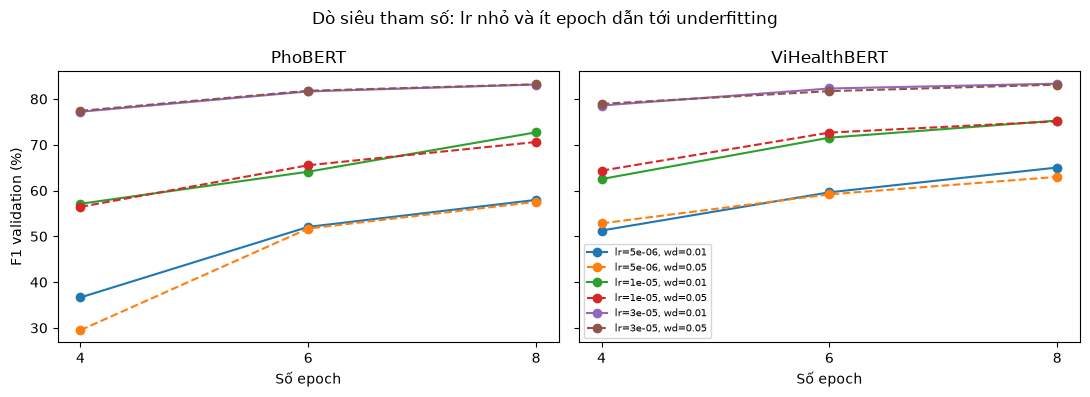

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (name, file) in zip(axes, [('PhoBERT', 'phobert_validation_sweep.json'), ('ViHealthBERT', 'vihealthbert_validation_sweep.json')]):
    trials = json.loads((PRIOR / file).read_text())['trials']
    for lr in sorted({t['learning_rate'] for t in trials}):
        for wd, style in ((0.01, '-'), (0.05, '--')):
            pts = sorted((t['epochs'], t['validation']['eval_f1'] * 100) for t in trials if t['learning_rate'] == lr and t['weight_decay'] == wd)
            ax.plot(*zip(*pts), style, marker='o', label=f'lr={lr:.0e}, wd={wd}')
    ax.set_title(name)
    ax.set_xlabel('Số epoch')
    ax.set_xticks([4, 6, 8])
axes[0].set_ylabel('F1 validation (%)')
axes[1].legend(fontsize=7)
fig.suptitle('Dò siêu tham số: lr nhỏ và ít epoch dẫn tới underfitting')
fig.tight_layout()
fig.savefig(RES / 'fig_sweep_underfitting.png', dpi=150)
plt.show()

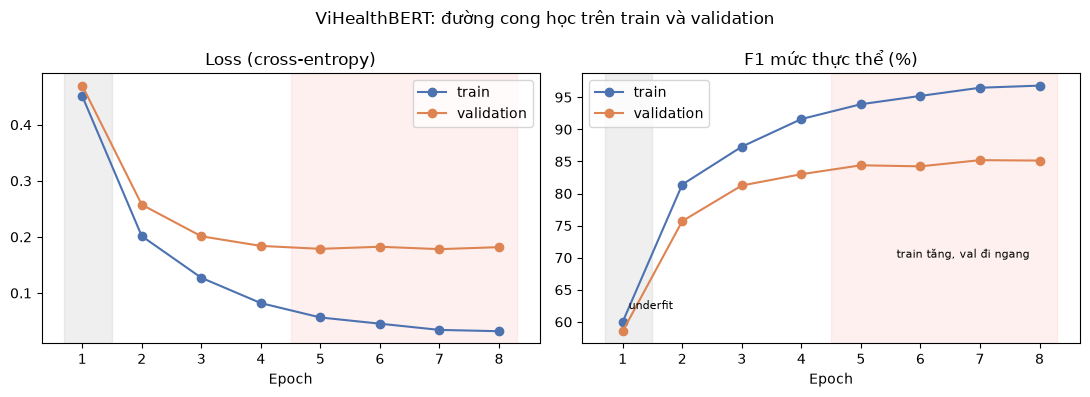

,epoch,train_loss_logged_mean,train_loss,train_f1,validation_loss,validation_f1
0,1,1.3374,0.4512,0.6001,0.4697,0.5854
1,2,0.3650,0.2014,0.8140,0.2575,0.7570
2,3,0.2098,0.1272,0.8730,0.2011,0.8125
3,4,0.1406,0.0820,0.9160,0.1840,0.8301
4,5,0.1014,0.0564,0.9391,0.1788,0.8440
5,6,0.0747,0.0453,0.9521,0.1825,0.8423
6,7,0.0600,0.0342,0.9648,0.1782,0.8520
7,8,0.0501,0.0319,0.9681,0.1818,0.8513


In [13]:
if RETRAIN_CURVE:
    from datasets import Dataset
    from transformers import DataCollatorForTokenClassification, Trainer, TrainerCallback, TrainingArguments

    BASE = 'demdecuong/vihealthbert-base-syllable'
    label2id = {l: i for i, l in enumerate(labels_all)}
    id2label = {i: l for l, i in label2id.items()}
    base_tok = AutoTokenizer.from_pretrained(BASE)

    def encode_train(words, tags):
        ids, lab = [base_tok.cls_token_id], [-100]
        for w, t in zip(words, tags):
            sub = base_tok.encode(w, add_special_tokens=False)
            if not sub:
                continue
            ids += sub
            lab += [label2id[t]] + [-100] * (len(sub) - 1)
        ids, lab = ids[:255] + [base_tok.sep_token_id], lab[:255] + [-100]
        return {'input_ids': ids, 'attention_mask': [1] * len(ids), 'labels': lab}

    ds = {s: Dataset.from_list([encode_train(w, t) for w, t in zip(*data[s])]) for s in SPLITS}

    def entity_f1(out):
        arg = out.predictions.argmax(-1)
        P, G = [], []
        for pr, gr in zip(arg, out.label_ids):
            keep = gr != -100
            P.append([id2label[int(v)] for v in pr[keep]])
            G.append([id2label[int(v)] for v in gr[keep]])
        return f1_score(G, P, zero_division=0)

    history = []

    class EpochLogger(TrainerCallback):
        trainer, losses = None, []

        def on_log(self, args, state, control, logs=None, **kw):
            if logs and 'loss' in logs:
                self.losses.append(logs['loss'])

        def on_epoch_end(self, args, state, control, **kw):
            row = {'epoch': round(state.epoch), 'train_loss_logged_mean': float(np.mean(self.losses)) if self.losses else None}
            self.losses = []
            for s in ('train', 'validation'):
                out = self.trainer.predict(ds[s])
                row[f'{s}_loss'] = float(out.metrics['test_loss'])
                row[f'{s}_f1'] = float(entity_f1(out))
            history.append(row)
            print(row)

    model = AutoModelForTokenClassification.from_pretrained(BASE, num_labels=len(labels_all), id2label=id2label, label2id=label2id)
    args = TrainingArguments(output_dir=str(ROOT / 'retrain_out'), learning_rate=3e-5, num_train_epochs=8, weight_decay=0.01,
                             per_device_train_batch_size=16, per_device_eval_batch_size=64, lr_scheduler_type='linear',
                             warmup_ratio=0.1, logging_steps=20, save_strategy='no', eval_strategy='no', seed=2024,
                             bf16=torch.cuda.is_available() and torch.cuda.is_bf16_supported(), report_to='none')
    cb = EpochLogger()
    trainer = Trainer(model=model, args=args, train_dataset=ds['train'], data_collator=DataCollatorForTokenClassification(base_tok), callbacks=[cb])
    cb.trainer = trainer
    trainer.train()
    curve = {'config': {'base': BASE, 'lr': 3e-5, 'epochs': 8, 'weight_decay': 0.01, 'seed': 2024, 'batch': 16, 'warmup_ratio': 0.1},
             'history': history, 'final_test_f1': float(entity_f1(trainer.predict(ds['test'])))}
else:
    curve = json.loads((PRIOR / 'vihealthbert_epoch_curve.json').read_text())
(RES / 'vihealthbert_epoch_curve.json').write_text(json.dumps(curve, indent=1))

h = curve['history']
ep = [r['epoch'] for r in h]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(ep, [r['train_loss'] for r in h], '-o', label='train', color='#4C72B0')
a1.plot(ep, [r['validation_loss'] for r in h], '-o', label='validation', color='#DD8452')
a1.set_title('Loss (cross-entropy)')
a2.plot(ep, [r['train_f1'] * 100 for r in h], '-o', label='train', color='#4C72B0')
a2.plot(ep, [r['validation_f1'] * 100 for r in h], '-o', label='validation', color='#DD8452')
a2.set_title('F1 mức thực thể (%)')
for a in (a1, a2):
    a.set_xlabel('Epoch')
    a.set_xticks(ep)
    a.legend()
    a.axvspan(0.7, 1.5, color='grey', alpha=0.12)
    a.axvspan(4.5, 8.3, color='red', alpha=0.06)
a2.text(1.1, 62, 'underfit', fontsize=8)
a2.text(5.6, 70, 'train tăng, val đi ngang', fontsize=8)
fig.suptitle('ViHealthBERT: đường cong học trên train và validation')
fig.tight_layout()
fig.savefig(RES / 'fig_vihealthbert_epoch_curve.png', dpi=150)
plt.show()
pd.DataFrame(h)

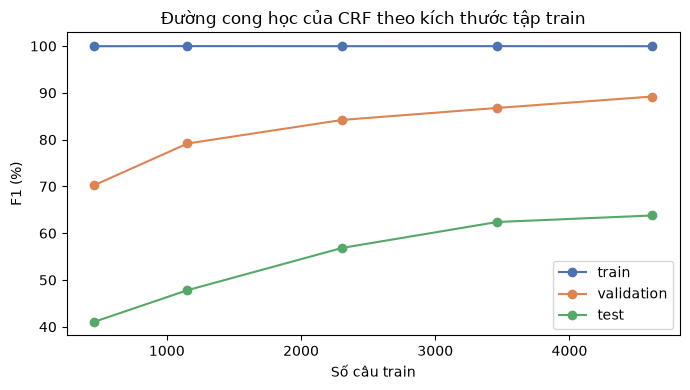

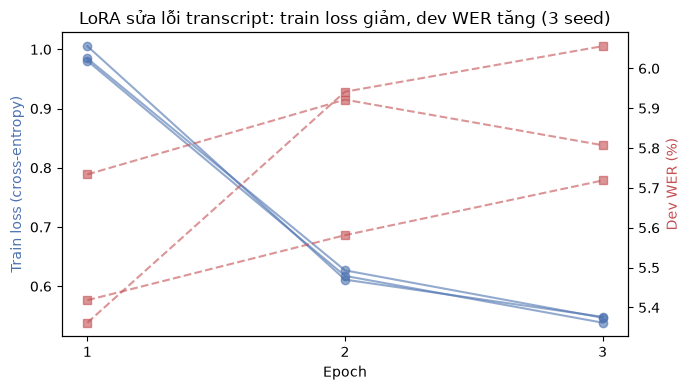

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
xs = [c['sentences'] for c in crf_curve]
for key, lab in [('train_f1', 'train'), ('validation_f1', 'validation'), ('test_f1', 'test')]:
    ax.plot(xs, [c[key] * 100 for c in crf_curve], marker='o', label=lab, color=COL[lab])
ax.set_xlabel('Số câu train')
ax.set_ylabel('F1 (%)')
ax.set_title('Đường cong học của CRF theo kích thước tập train')
ax.legend()
fig.tight_layout()
fig.savefig(RES / 'fig_crf_learning_curve.png', dpi=150)
plt.show()

runs = json.loads((PRIOR / 'lora_training_runs.json').read_text())
fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()
for r in runs:
    e = [x['epoch'] for x in r['history']]
    ax1.plot(e, [x['token_cross_entropy'] for x in r['history']], '-o', color='#4C72B0', alpha=0.6)
    ax2.plot(e, [x['dev_wer'] * 100 for x in r['history']], '--s', color='#C44E52', alpha=0.6)
ax1.set_xlabel('Epoch')
ax1.set_xticks([1, 2, 3])
ax1.set_ylabel('Train loss (cross-entropy)', color='#4C72B0')
ax2.set_ylabel('Dev WER (%)', color='#C44E52')
ax1.set_title('LoRA sửa lỗi transcript: train loss giảm, dev WER tăng (3 seed)')
fig.tight_layout()
fig.savefig(RES / 'fig_lora_overfitting.png', dpi=150)
plt.show()

## 8. Confusion matrix và phân loại lỗi

Confusion matrix mức token (gộp B-/I- về loại thực thể), chuẩn hoá theo hàng. Ở mức thực thể, mỗi dự đoán được xếp vào: khớp hoàn toàn, lệch ranh giới, sai loại, bỏ sót, đoán thừa.

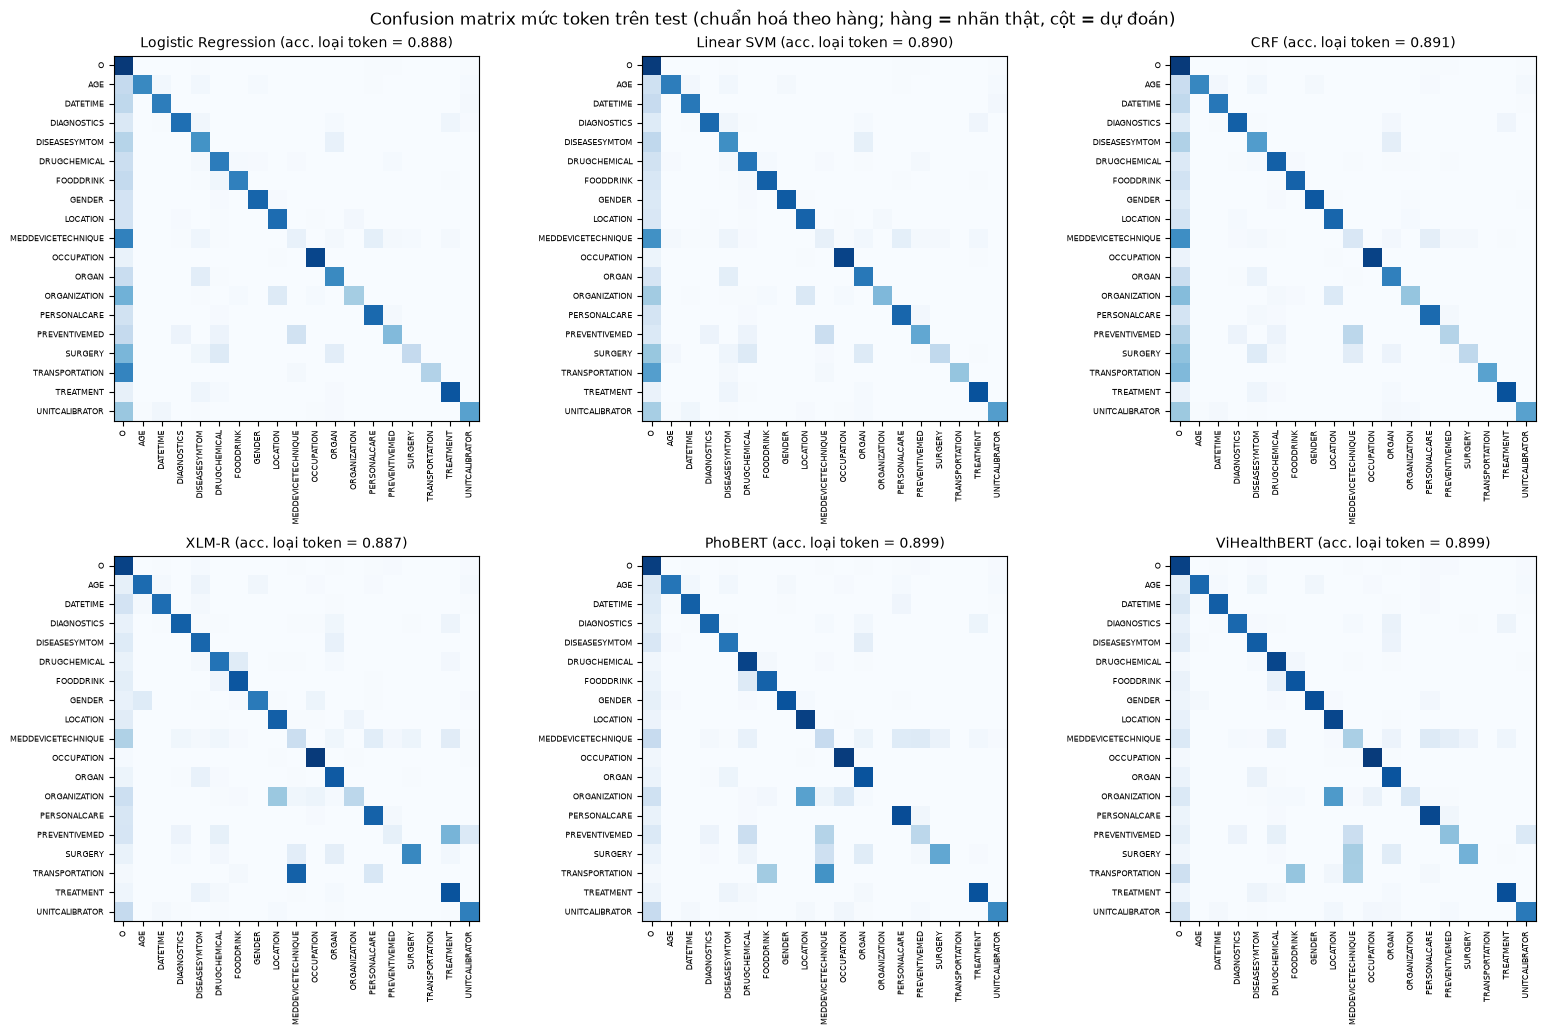

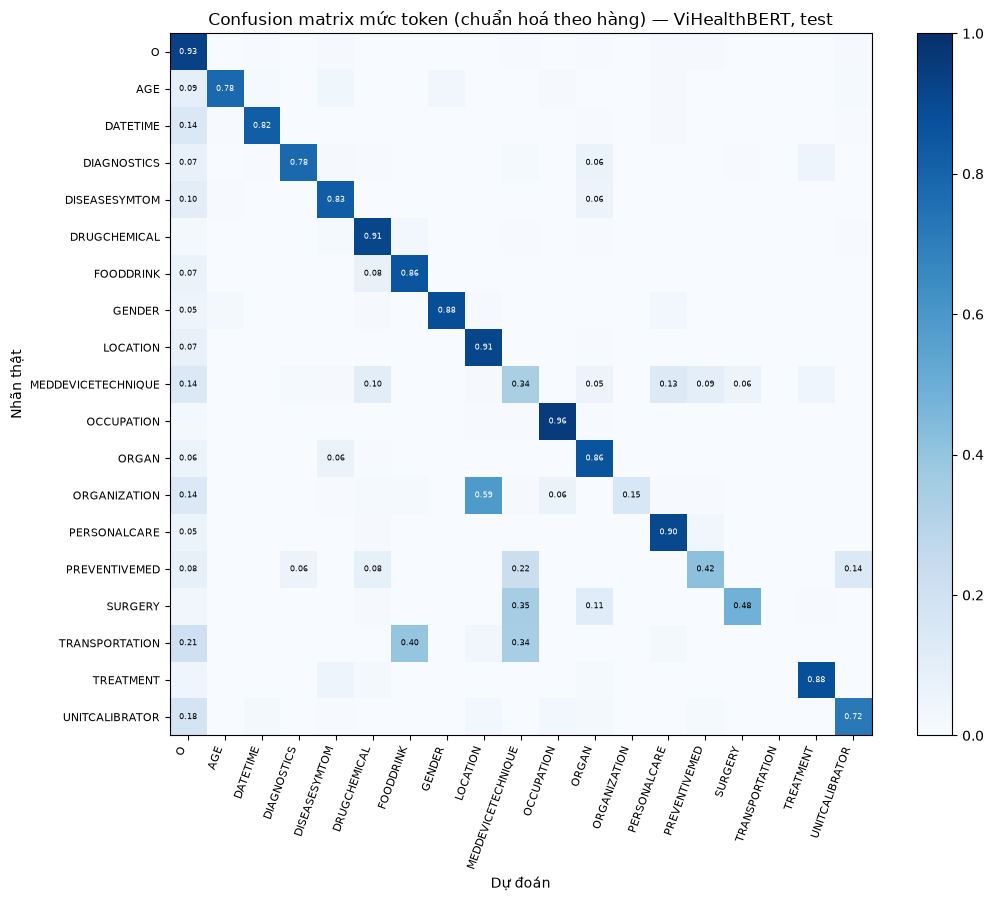

,exact,boundary,wrong_type,missed,spurious
Logistic Regression,4820,1871,200,1447,1420
Linear SVM,5177,1865,189,1107,1640
CRF,5164,1429,171,1574,1052
XLM-R,5523,1797,463,555,2177
PhoBERT,5786,1644,424,484,1796
ViHealthBERT,5923,1622,441,352,2089


In [15]:
def token_type(t):
    return 'O' if t == 'O' else t.split('-', 1)[1]


cm_labels = ['O'] + sorted(types)
cms = {}
fig, axes = plt.subplots(2, 3, figsize=(16, 10.5))
for ax, m in zip(axes.flat, ORDER):
    idx = {l: i for i, l in enumerate(cm_labels)}
    cm = np.zeros((len(cm_labels), len(cm_labels)), dtype=int)
    for g, p in zip(gold, preds['test'][m]):
        for a, b in zip(g, p):
            cm[idx[token_type(a)], idx[token_type(b)]] += 1
    cms[m] = cm
    norm = cm / cm.sum(1, keepdims=True).clip(min=1)
    ax.imshow(norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'{m} (acc. loại token = {np.trace(cm) / cm.sum():.3f})', fontsize=10)
    ax.set_xticks(range(len(cm_labels)), cm_labels, rotation=90, fontsize=5.5)
    ax.set_yticks(range(len(cm_labels)), cm_labels, fontsize=5.5)
fig.suptitle('Confusion matrix mức token trên test (chuẩn hoá theo hàng; hàng = nhãn thật, cột = dự đoán)')
fig.tight_layout()
fig.savefig(RES / 'fig_confusion_all_models.png', dpi=150)
plt.show()
(RES / 'confusion_all_models.json').write_text(json.dumps({'labels': cm_labels, 'matrices': {m: c.tolist() for m, c in cms.items()}}))

norm = cms['ViHealthBERT'] / cms['ViHealthBERT'].sum(1, keepdims=True).clip(min=1)
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(norm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(cm_labels)), cm_labels, rotation=70, ha='right', fontsize=8)
ax.set_yticks(range(len(cm_labels)), cm_labels, fontsize=8)
ax.set_xlabel('Dự đoán')
ax.set_ylabel('Nhãn thật')
ax.set_title('Confusion matrix mức token (chuẩn hoá theo hàng) — ViHealthBERT, test')
for i in range(len(cm_labels)):
    for j in range(len(cm_labels)):
        if norm[i, j] >= 0.05:
            ax.text(j, i, f'{norm[i, j]:.2f}', ha='center', va='center', fontsize=6, color='white' if norm[i, j] > 0.5 else 'black')
fig.colorbar(im)
fig.tight_layout()
fig.savefig(RES / 'fig_confusion_vihealthbert.png', dpi=150)
plt.show()

pd.DataFrame({m: summary[m]['span_outcomes'] for m in ORDER}).T[['exact', 'boundary', 'wrong_type', 'missed', 'spurious']]

In [16]:
# Các cặp nhầm loại phổ biến nhất của ViHealthBERT (thực thể thật chồng lấn với dự đoán khác loại)
confused = Counter()
for ws, gt, pt in zip(words, gold, preds['test']['ViHealthBERT']):
    ps = {(a, b): t for t, a, b in get_entities(pt)}
    for t, s, e in get_entities(gt):
        for (a, b), pty in ps.items():
            if a <= e and s <= b and pty != t:
                confused[(t, pty, ' '.join(ws[s:e + 1]), ' '.join(ws[a:b + 1]))] += 1
pd.DataFrame([{'nhãn thật': k[0], 'dự đoán': k[1], 'cụm thật': k[2], 'cụm dự đoán': k[3], 'số lần': v}
              for k, v in confused.most_common(15)])

,nhãn thật,dự đoán,cụm thật,cụm dự đoán,số lần
0,SURGERY,MEDDEVICETECHNIQUE,implant,implant,40
1,MEDDEVICETECHNIQUE,PERSONALCARE,chăm sóc,chăm sóc,30
2,MEDDEVICETECHNIQUE,PREVENTIVEMED,tránh thai,tránh thai,27
3,DISEASESYMTOM,ORGAN,tiêu xương,xương,24
4,ORGAN,DISEASESYMTOM,xương,tiêu xương,21
5,DIAGNOSTICS,TREATMENT,khám,thăm khám,19
6,GENDER,PERSONALCARE,mẹ,bú mẹ,15
7,SURGERY,MEDDEVICETECHNIQUE,cấy que tránh thai,cấy que tránh thai,14
8,SURGERY,ORGAN,ghép xương,xương,14
9,MEDDEVICETECHNIQUE,DRUGCHEMICAL,que tránh thai,que tránh thai,13


## 9. Phân tích lỗi theo độ khó của mẫu

Với văn bản, "độ khó" tương ứng với việc thực thể đã xuất hiện trong train hay chưa, và độ dài câu. Ngoài ra đếm số lần mô hình sinh chuỗi nhãn BIO không hợp lệ.

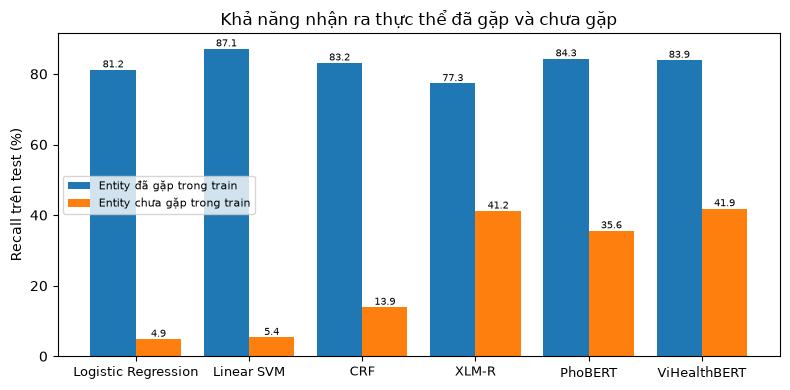

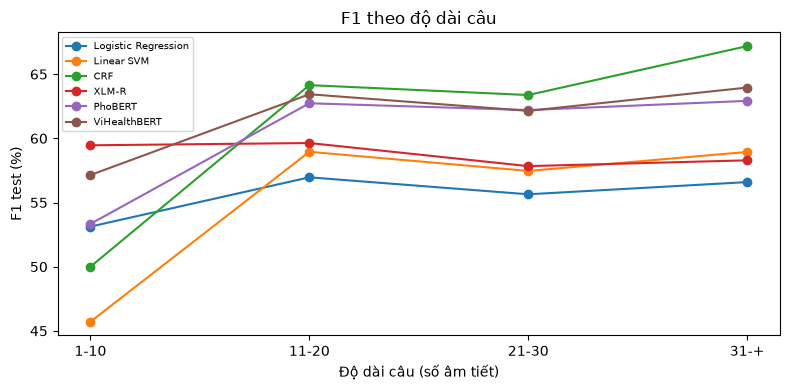

,recall_seen,recall_unseen,invalid_bio_transitions
Logistic Regression,0.8120,0.0489,1127.0
Linear SVM,0.8715,0.0540,1175.0
CRF,0.8315,0.1393,9.0
XLM-R,0.7731,0.4120,778.0
PhoBERT,0.8433,0.3560,600.0
ViHealthBERT,0.8393,0.4186,595.0


In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(ORDER))
b1 = ax.bar(x - 0.2, [summary[m]['recall_seen'] * 100 for m in ORDER], 0.4, label='Entity đã gặp trong train')
b2 = ax.bar(x + 0.2, [summary[m]['recall_unseen'] * 100 for m in ORDER], 0.4, label='Entity chưa gặp trong train')
ax.bar_label(b1, fmt='%.1f', fontsize=7)
ax.bar_label(b2, fmt='%.1f', fontsize=7)
ax.set_xticks(x, ORDER, fontsize=9)
ax.set_ylabel('Recall trên test (%)')
ax.set_title('Khả năng nhận ra thực thể đã gặp và chưa gặp')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(RES / 'fig_seen_unseen.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
for m in ORDER:
    ax.plot(list(summary[m]['f1_by_sentence_length']), [v['f1'] * 100 for v in summary[m]['f1_by_sentence_length'].values()], marker='o', label=m)
ax.set_xlabel('Độ dài câu (số âm tiết)')
ax.set_ylabel('F1 test (%)')
ax.set_title('F1 theo độ dài câu')
ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(RES / 'fig_f1_by_length.png', dpi=150)
plt.show()


def invalid_transitions(pred):
    n_bad = 0
    for row in pred:
        prev = 'O'
        for t in row:
            if t.startswith('I-') and not (prev != 'O' and prev[2:] == t[2:]):
                n_bad += 1
            prev = t
    return n_bad


pd.DataFrame({m: {'recall_seen': summary[m]['recall_seen'], 'recall_unseen': summary[m]['recall_unseen'],
                  'invalid_bio_transitions': invalid_transitions(preds['test'][m])} for m in ORDER}).T

In [18]:
# Ví dụ: thực thể chưa gặp trong train — so sánh CRF và ViHealthBERT
def show(i):
    ws = words[i]
    fmt = lambda tags: [(' '.join(ws[s:e + 1]), t) for t, s, e in get_entities(tags)]
    return {'câu': ' '.join(ws), 'nhãn thật': fmt(gold[i]), 'ViHealthBERT': fmt(preds['test']['ViHealthBERT'][i]), 'CRF': fmt(preds['test']['CRF'][i])}


examples = [i for i, ws in enumerate(words) if any(k in ' '.join(ws) for k in ('rong huyết', 'tiêu xương', 'trồng răng implant'))][:3]
pd.DataFrame([show(i) for i in examples])

,câu,nhãn thật,ViHealthBERT,CRF
0,đúng ngày kinh của mình nhưng mà ngày kinh kéo...,"[(ngày kinh, DATETIME), (ngày kinh, DATETIME),...","[(kinh, DATETIME), (bảy ngày, DATETIME), (rong...","[(bảy ngày, DATETIME), (huyết, ORGAN)]"
1,rong huyết như vậy mình sẽ phân biệt với rong ...,"[(rong huyết, DISEASESYMTOM), (rong kinh, DISE...","[(rong huyết, DISEASESYMTOM), (rong kinh, DISE...","[(huyết, ORGAN), (huyết, ORGAN)]"
2,thì đừng là gây nên rong huyết còn nếu mà u xơ...,"[(rong huyết, DISEASESYMTOM), (u xơ tử cung, D...","[(rong huyết, DISEASESYMTOM), (u xơ tử cung, D...","[(huyết, ORGAN)]"


## 10. Kết luận

- Theo F1 strict trên test, **CRF** tốt nhất; lợi thế so với ViHealthBERT nhỏ nhưng có ý nghĩa thống kê (xem bảng bootstrap). ViHealthBERT và PhoBERT ngang nhau.
- CRF vượt rõ hai mô hình phân loại từng token dùng cùng đặc trưng, nhờ mô hình hoá chuyển nhãn (rất ít chuỗi BIO không hợp lệ).
- CRF thắng nhờ ghi nhớ từ vựng (69% thực thể test đã gặp trong train); với thực thể chưa gặp, ViHealthBERT nhận ra nhiều gấp khoảng 3 lần.
- Mọi mô hình được huấn luyện đều overfit tập train; khoảng cách validation → test (lệch miền) lớn hơn khoảng cách train → validation.
- Chi tiết phân tích, bảng và hình nằm trong báo cáo Word (thư mục `bao_cao/`), được sinh từ `results/` bằng `bao_cao/build_docx.js`.